In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv("SOCR-HeightWeight (1).csv")
df.head()
df.shape

(25000, 3)

In [ ]:
x=df[['Height(Inches)']]
y=df['Weight(Pounds)']

In [ ]:
df.isna().sum()

,0
Index,0
Height(Inches),0
Weight(Pounds),0


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

In [ ]:
y_test

,Weight(Pounds)
23676,110.1330
22121,108.9518
10634,116.1544
18994,120.1020
10547,110.3270
...,...
10523,133.3322
23577,139.9702
20730,129.3491
4370,112.4388


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Absolute Error (MAE): 7.99
Mean Squared Error (MSE): 99.97
R-squared (R2) Score: 0.26


In [ ]:
import joblib
joblib.dump(model,'linear.pk')

['linear.pk']

In [ ]:
!pip install pyspark --quiet


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

spark=SparkSession.builder \
     .appName('Day4_BigData_Sales') \
     .config('spark.sql.adaptive.enables','true') \
     .getOrCreate()

print(f'Spark Version: {spark.version}')
print(f'SparkSession : ACTIVE')
print(f'Application  : {spark.sparkContext.appName}')

Spark Version: 4.0.2
SparkSession : ACTIVE
Application  : Day4_BigData_Sales


In [ ]:
df_bronze = spark.read \
   .option('header', 'true') \
   .option('inferSchema','true') \
   .csv('large_sales_data.csv')

print('===BRONZE LAYER - Raw Data===')
print(f"Rows  : {df_bronze.count()}")

print(f"Columns  : {len(df_bronze.columns)}")
print(f'Names :   {df_bronze.columns}')
print()
df_bronze.printSchema()

===BRONZE LAYER - Raw Data===
Rows  : 5000
Columns  : 13
Names :   ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
print('First 5 rows:')
df_bronze.show(5, truncate=False)

print('\n Basic statistics for numeric columns:')
df_bronze.select('quantity', 'unit_price', 'revenue').describe().show()

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [ ]:
df_bronze.write \
   .mode("Overwrite") \
   .parquet('sales_bronze.parquet')

print("Bronze Parquet saved: sales_beonze.parquet")



Bronze Parquet saved: sales_beonze.parquet


In [ ]:
df_silver= df_bronze \
    .dropDuplicates() \
    .dropna(subset=['order_id','product','revenue'])

df_silver = df_silver.withColumn(
    'order_date',
    to_date(col('order_date'),'yyyy-mm-dd')
)

df_silver = df_silver\
    .withColumn('order_year',year(col('order_date'))) \
    .withColumn('order_month', month(col('order_date')))

df_silver= df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue') > 40000, "High")
    .when(col('revenue') > 10000, "Medium")
    .otherwise('Low')
)
print(f'Silver Layer Rows : {df_silver.count()}')
print(f" New Columns added: order_year,order_month,revenue_category")
df_silver.select("Product","revenue","order_year","order_month","revenue_category").show(8)


Silver Layer Rows : 5000
 New Columns added: order_year,order_month,revenue_category
+----------+-------+----------+-----------+----------------+
|   Product|revenue|order_year|order_month|revenue_category|
+----------+-------+----------+-----------+----------------+
|  Keyboard|  13200|      2023|          2|          Medium|
|    Webcam|  17500|      2023|          1|          Medium|
|   Speaker|  58500|      2023|          4|            High|
|  Keyboard|   9600|      2023|         12|             Low|
|    Laptop| 180000|      2023|          8|            High|
|Headphones|  38500|      2023|          5|          Medium|
|    Webcam|  35000|      2023|         11|          Medium|
|    Laptop| 360000|      2023|          1|            High|
+----------+-------+----------+-----------+----------------+
only showing top 8 rows


In [ ]:
from os.path import isfile
import os

def get_dir_size(path):
  """ Get total size of a file or directory in KB."""
  if os.path.isfile(path):
    return os.path.getsize(path)/1024
  total = 0
  for dirpath,dirnames, filenames in os.walk(path):
    for f in filenames:
      total +=os.path.getsize(os.path.join(dirpath,f))
  return total/1024

  csv_size=grt_dir_size("large_sales_data.csv")
  paraquet_size=get_dir_size("sales_bronze.paraquet")

In [ ]:
df_silver.write \
    .mode('overwrite') \
    .parquet('sales_silver.parquet')

print("Silver Parquet saved: sales_silver.parquet")

df_verify = spark.read.parquet('sales_silver.parquet')
print(f"Read-back rows:{ df_verify.count()} (should match Silver Count)")
df_verify.printSchema()

Silver Parquet saved: sales_silver.parquet
Read-back rows:5000 (should match Silver Count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [ ]:
top_products = df_silver \
    .groupBy('Product') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('num_orders'),
        F.avg('revenue').alias('avg_order_revenue')
    ) \
    .orderBy('total_revenue', ascending=False) \
    .limit(5)

print('=== Top 5 Products by Revenue ===')
top_products.show(truncate=False)

=== Top 5 Products by Revenue ===
+-------+-------------+----------+------------------+
|Product|total_revenue|num_orders|avg_order_revenue |
+-------+-------------+----------+------------------+
|Laptop |182700000    |502       |363944.22310756973|
|Tablet |135104000    |532       |253954.8872180451 |
|Monitor|82126000     |481       |170740.12474012474|
|Printer|44544000     |488       |91278.68852459016 |
|Speaker|16317000     |470       |34717.02127659575 |
+-------+-------------+----------+------------------+



In [ ]:
gold_products=df_silver \
.groupBy('product','category') \
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('units_sold'),
    spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
    F.max('revenue').alias('largest_order')
) \
.orderBy('total_revenue',ascending=False)
gold_products.write.mode('overwrite').parquet('gold_product_summary.parquet')

In [ ]:
monthly_trend=df_silver \
    .groupBy('order_month') \
    .agg(F.sum('revenue').alias('monthly_revenue'),
         F.count('order_id').alias('monthly_orders')) \
    .orderBy('order_month')

print("=== Monthly Revenue Trend ===")
monthly_trend.show(12)


=== Monthly Revenue Trend ===
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|          1|       41068200|           423|
|          2|       34485400|           375|
|          3|       40031200|           451|
|          4|       38857100|           390|
|          5|       39984500|           423|
|          6|       40707400|           390|
|          7|       42640700|           405|
|          8|       43718500|           418|
|          9|       37640200|           398|
|         10|       47839000|           479|
|         11|       44577100|           419|
|         12|       44298300|           429|
+-----------+---------------+--------------+



In [ ]:
gold_region = df_silver \
    .groupBy('region') \
    .agg(F.sum('revenue').alias('total_revenue')) \
    .orderBy('total_revenue', ascending=False)
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')

In [ ]:
gold_products=df_silver \
.groupBy('product','category') \
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('units_sold'),
    spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
    F.max('revenue').alias('largest_order')
) \
.orderBy('total_revenue',ascending=False)
gold_products.write.mode('overwrite').parquet('gold_product_summary.parquet')

In [ ]:
monthly_trend=df_silver \
.groupBy('order_month') \
.agg(
    F.sum('revenue').alias('monthly_revenue'),
    F.count('order_id').alias('monthly_orders')) \
    .orderBy('order_month')
monthly_trend.write.mode('overwrite').parquet('gold_monthly_trend.parquet')
print('=== Monthly Revenue Trend ===')
monthly_trend.show(12)

=== Monthly Revenue Trend ===
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|          1|       41068200|           423|
|          2|       34485400|           375|
|          3|       40031200|           451|
|          4|       38857100|           390|
|          5|       39984500|           423|
|          6|       40707400|           390|
|          7|       42640700|           405|
|          8|       43718500|           418|
|          9|       37640200|           398|
|         10|       47839000|           479|
|         11|       44577100|           419|
|         12|       44298300|           429|
+-----------+---------------+--------------+



In [ ]:
region_pd = spark.read.parquet("gold_region_revenue.parquet").toPandas()
product_pd = spark.read.parquet("gold_product_summary.parquet").toPandas()
monthly_pd = spark.read.parquet("gold_monthly_trend.parquet").toPandas()

print("Gold Tables converted to Pandas:")
print(f" Region : {region_pd.shape}")
print(f" Products : {product_pd.shape}")
print(f" Monthly : {monthly_pd.shape}")

region_pd = region_pd.sort_values('total_revenue' , ascending=False)
product_pd = product_pd.sort_values('total_revenue', ascending =False)
monthly_pd = monthly_pd.sort_values("order_month")

Gold Tables converted to Pandas:
 Region : (4, 2)
 Products : (10, 6)
 Monthly : (12, 3)


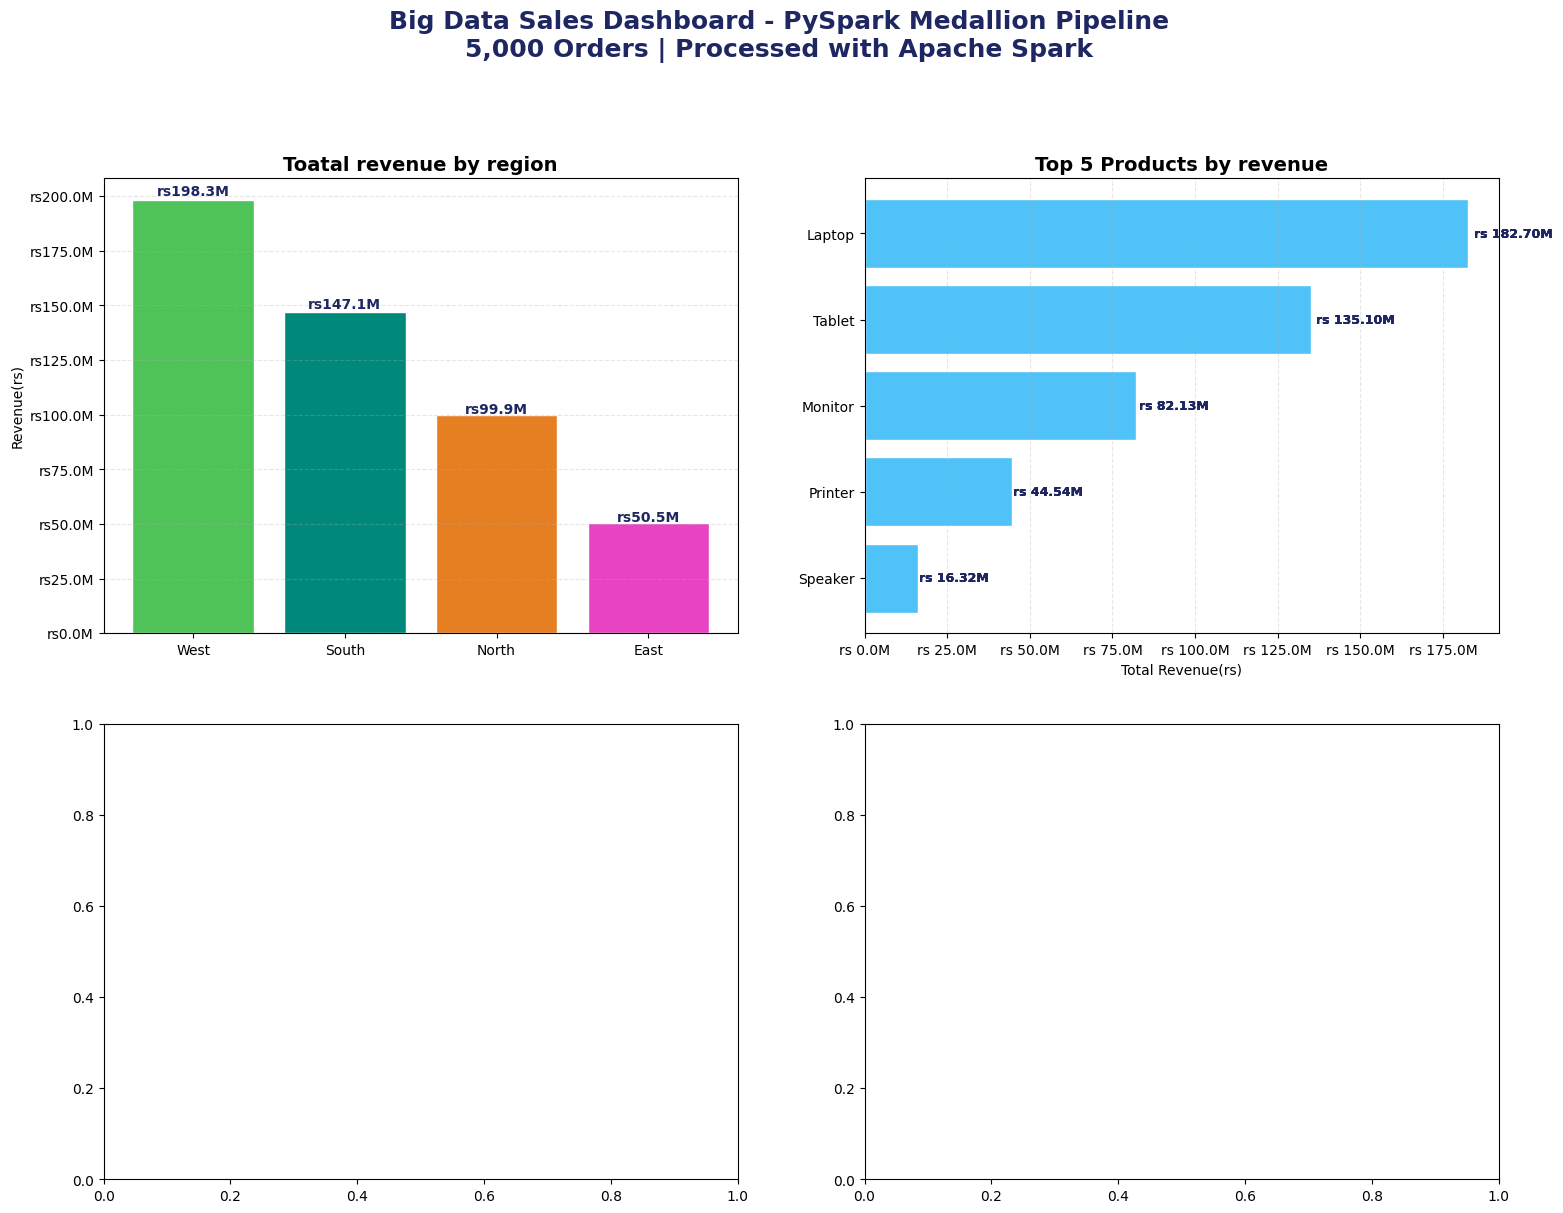

In [ ]:
fig,axes = plt.subplots(2,2,figsize=(18,13))
fig.suptitle(
    'Big Data Sales Dashboard - PySpark Medallion Pipeline\n'
    '5,000 Orders | Processed with Apache Spark',
    fontsize=18, fontweight='bold', color='#1E2761',y=1.01
)

colors4 = ['#4FC357','#00897B','#E67E22','#E743C3']

ax1= axes[0][0]
bars1 = ax1.bar(region_pd['region'], region_pd['total_revenue'],
                color=colors4[:len(region_pd)], edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
           f'rs{bar.get_height()/1e6:.1f}M',
           ha='center', fontsize=10, fontweight='bold',color='#1E2761')
  ax1.set_title("Toatal revenue by region",fontsize=14, fontweight='bold')
  ax1.set_ylabel('Revenue(rs)')
  ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'rs{x/1e6:.1f}M'))
  ax1.grid(axis='y', alpha=0.3,linestyle='--')
  ax2=axes[0][1]
  top5_prod = product_pd.head(5).sort_values('total_revenue')
  bars2 = ax2.barh(top5_prod['product'], top5_prod['total_revenue'],
                   color="#4FC3F7", edgecolor='white')
  for bar in bars2:
     ax2.text(bar.get_width()*1.01, bar.get_y() + bar.get_height()/2,
              f'rs {bar.get_width()/1e6:.2f}M',
              va='center', fontsize=9, fontweight='bold', color='#1E2761')
     ax2.set_title('Top 5 Products by revenue', fontsize=14, fontweight='bold')
     ax2.set_xlabel("Total Revenue(rs)")
     ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"rs {x/1e6:.1f}M"))
     ax2.grid(axis='x',alpha=0.3,linestyle='--')


In [ ]:
print('==== Activity 2: File formatting Comparison ===')
print()

csv_kb    =get_dir_size("large_sales_data.csv")
bronze_kb =get_dir_size("sales_bronze.parquet")
silver_kb =get_dir_size("sales_silver.parquet")
gold_kb   =(get_dir_size("gold_region_revenue.parquet") +
           get_dir_size("gold_product_summary.parquet")+
           get_dir_size("gold_monthly_trend.parquet"))

print(f"{'File':<38} {'Size (KB)':>10} {'vs CSV': >10}")

==== Activity 2: File formatting Comparison ===

File                                    Size (KB)     vs CSV
